# cnamuangtoun Dataset Exploration

**Goal:** Find JDs with enough Good Fit resumes for meaningful evaluation.

**Minimum:** Each selected JD must have at least 5 Good Fit resumes.

**Output:** Selected JDs + candidate pools → ready for file conversion.

In [1]:
!pip install datasets pandas matplotlib -q

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('Loading dataset...')
ds = load_dataset('cnamuangtoun/resume-job-description-fit', split='train')
df = pd.DataFrame(ds)
print(f'Loaded {len(df):,} rows')
print(f'Columns: {df.columns.tolist()}')

Loading dataset...


train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

Loaded 6,241 rows
Columns: ['resume_text', 'job_description_text', 'label']


---
## Step 1 — Dataset Overview

DATASET OVERVIEW
  Total pairs      : 6,241
  Unique resumes   : 642
  Unique JDs       : 280
  Avg pairs per JD : 22.3

Label distribution:
  No Fit              : 3,143 (50.4%)
  Potential Fit       : 1,556 (24.9%)
  Good Fit            : 1,542 (24.7%)


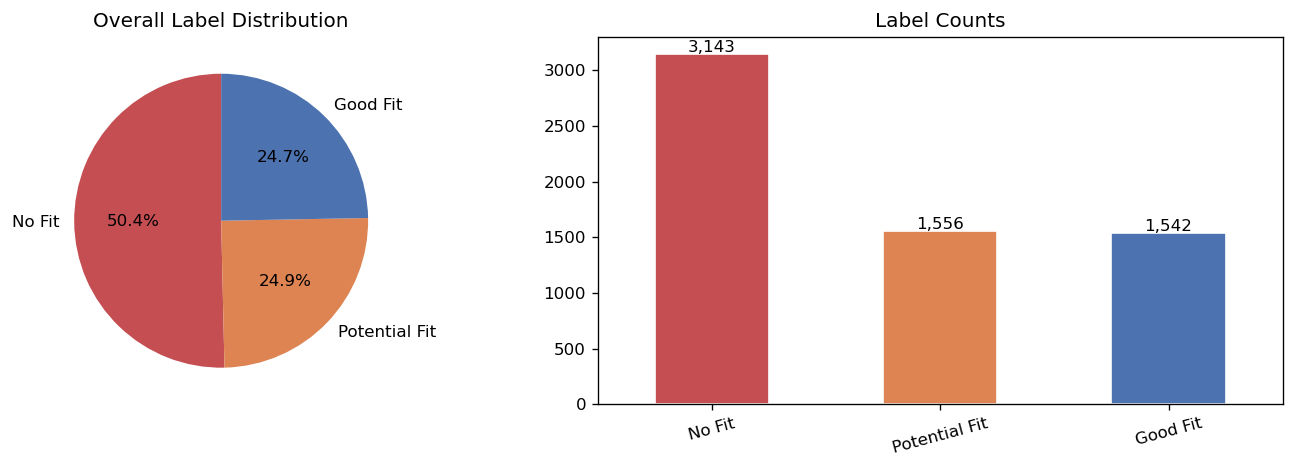

Saved: 01_label_distribution.png


In [3]:
# ── Basic stats ────────────────────────────────────────────────
unique_resumes = df['resume_text'].nunique()
unique_jds     = df['job_description_text'].nunique()
avg_per_jd     = len(df) / unique_jds

print('DATASET OVERVIEW')
print('='*45)
print(f'  Total pairs      : {len(df):,}')
print(f'  Unique resumes   : {unique_resumes:,}')
print(f'  Unique JDs       : {unique_jds:,}')
print(f'  Avg pairs per JD : {avg_per_jd:.1f}')
print()
print('Label distribution:')
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f'  {label:20}: {count:5,} ({pct:.1f}%)')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#C44E52','#DD8452','#4C72B0']
label_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                  colors=colors, startangle=90)
axes[0].set_title('Overall Label Distribution')
axes[0].set_ylabel('')
label_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Label Counts')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()+20),
                     ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_label_distribution.png')

---
## Step 2 — Per JD: how many resumes per label?

Per JD label count statistics:

                         Good Fit  Potential     No Fit      Total
  ------------------------------------------------------
  mean                        5.5        5.6       11.2       22.3
  min                         0.0        0.0        0.0        1.0
  max                        45.0       26.0       76.0      111.0

Good Fit count distribution per JD:
    0 Good Fit:  165 JDs  ██████████████████████████████████████████████████████████████████████████████████
    1 Good Fit:   29 JDs  ██████████████
    2 Good Fit:   15 JDs  ███████
    3 Good Fit:    6 JDs  ███
    4 Good Fit:    2 JDs  █
    6 Good Fit:    1 JDs  
    7 Good Fit:    1 JDs  
    8 Good Fit:    1 JDs  
   10 Good Fit:    3 JDs  █
   11 Good Fit:    1 JDs  
   12 Good Fit:    1 JDs  
   13 Good Fit:    2 JDs  █
   15 Good Fit:    3 JDs  █
   16 Good Fit:    1 JDs  
   17 Good Fit:    3 JDs  █
   18 Good Fit:    2 JDs  █
   19 Good Fit:    1 JDs  
   20 Good Fit:    3 JDs  █
   21 G

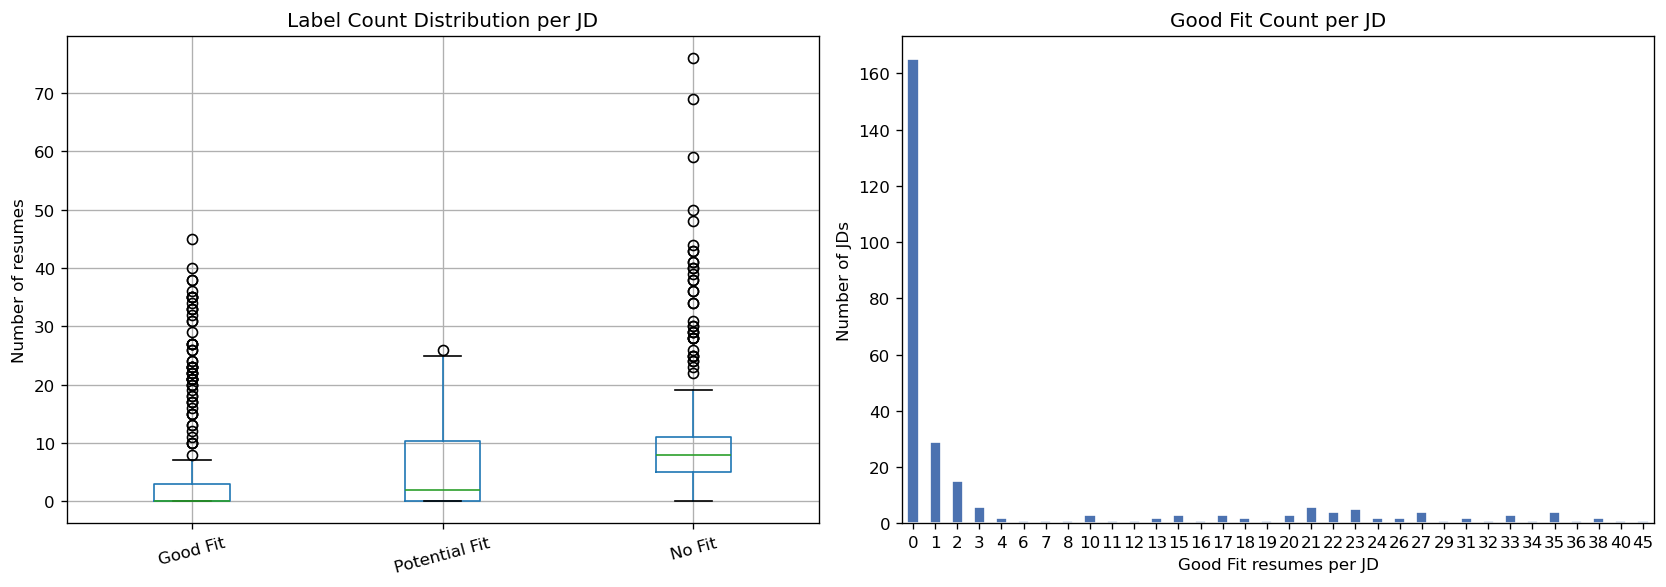

Saved: 02_per_jd_label_counts.png


In [4]:
# ── Per JD label counts ────────────────────────────────────────
jd_label = df.groupby(['job_description_text','label']).size().unstack(fill_value=0)
jd_label.columns.name = None
jd_label['total'] = jd_label.sum(axis=1)

col_good = [c for c in jd_label.columns if 'Good'      in str(c)][0]
col_pot  = [c for c in jd_label.columns if 'Potential' in str(c)][0]
col_no   = [c for c in jd_label.columns if 'No'        in str(c)][0]

print('Per JD label count statistics:')
print()
print(f'  {"":20} {"Good Fit":>10} {"Potential":>10} {"No Fit":>10} {"Total":>10}')
print('  ' + '-'*54)
for stat in ['mean','min','max']:
    row = jd_label[[col_good, col_pot, col_no, 'total']].agg(stat)
    print(f'  {stat:<20} {row[col_good]:>10.1f} {row[col_pot]:>10.1f} '
          f'{row[col_no]:>10.1f} {row["total"]:>10.1f}')

print()
gf_dist = jd_label[col_good].value_counts().sort_index()
print('Good Fit count distribution per JD:')
for val, count in gf_dist.items():
    bar = chr(9608) * (count // 2)
    print(f'  {int(val):3} Good Fit: {count:4} JDs  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
jd_label[[col_good, col_pot, col_no]].boxplot(ax=axes[0])
axes[0].set_title('Label Count Distribution per JD')
axes[0].set_ylabel('Number of resumes')
axes[0].tick_params(axis='x', rotation=15)
gf_dist.plot(kind='bar', ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Good Fit Count per JD')
axes[1].set_xlabel('Good Fit resumes per JD')
axes[1].set_ylabel('Number of JDs')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('02_per_jd_label_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_per_jd_label_counts.png')

---
## Step 3 — Filter: JDs with >= 5 Good, >= 8 Potential, >= 7 No Fit


JDs with >= 5 Good, >= 8 Potential, >= 7 No Fit: 11 / 280

    JD    Good   Potential    No Fit    Total
  ----------------------------------------
  JD01      36           9        25       70
  JD02      31           9        43       83
  JD03      29          13        69      111
  JD04      27           9        38       74
  JD05      26           9        50       85
  JD06      23           8        12       43
  JD07      21          12        29       62
  JD08      18          12        28       58
  JD09      10          12        13       35
  JD10      10          17        11       38
  JD11       6          11        10       27


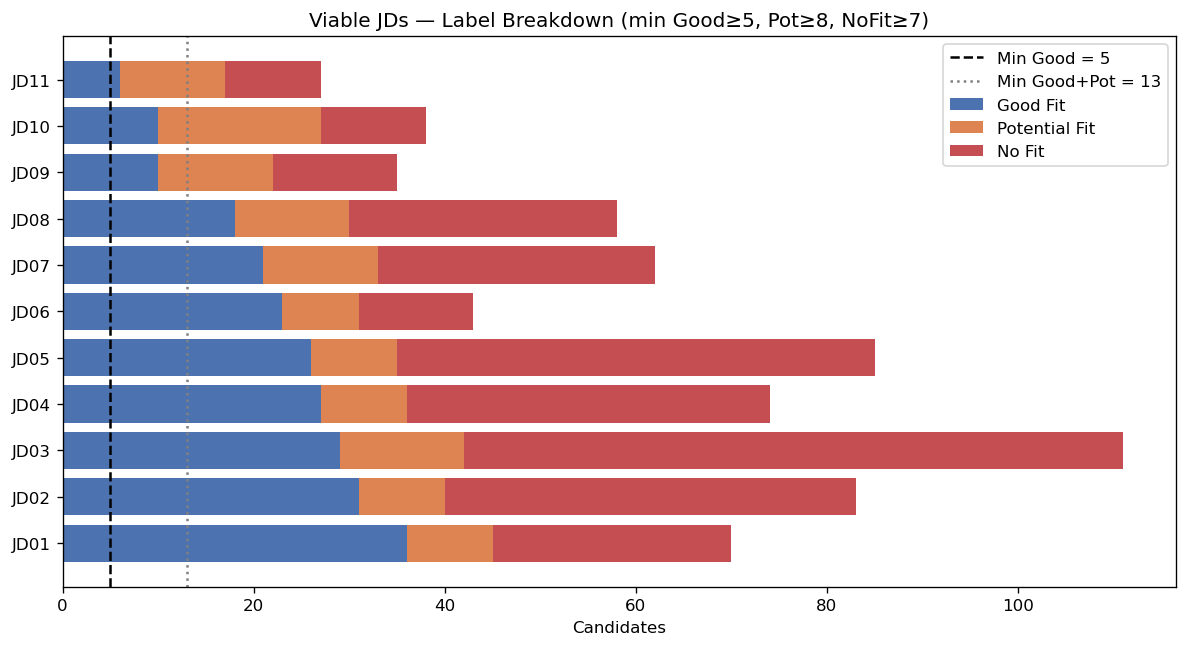

Saved: 03_viable_jds.png


In [21]:
MIN_GOOD = 5
MIN_POTENTIAL = 8
MIN_NOFIT = 7

# Filter JDs meeting ALL three minimums
viable_jds = jd_label[
    (jd_label[col_good] >= MIN_GOOD) &
    (jd_label[col_pot] >= MIN_POTENTIAL) &
    (jd_label[col_no] >= MIN_NOFIT)
].copy()
viable_jds = viable_jds.sort_values(col_good, ascending=False)

print(f'JDs with >= {MIN_GOOD} Good, >= {MIN_POTENTIAL} Potential, >= {MIN_NOFIT} No Fit: {len(viable_jds)} / {len(jd_label)}')
print()
print(f'  {"JD":>4}  {"Good":>6}  {"Potential":>10}  {"No Fit":>8}  {"Total":>7}')
print('  ' + '-'*40)
for i, (_, row) in enumerate(viable_jds.iterrows(), 1):
    print(f'  JD{i:02d}  {int(row[col_good]):>6}  {int(row[col_pot]):>10}  '
          f'{int(row[col_no]):>8}  {int(row["total"]):>7}')

if len(viable_jds) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(viable_jds)*0.5)))
    y = range(len(viable_jds))
    labels = [f'JD{i+1:02d}' for i in range(len(viable_jds))]
    ax.barh(list(y), viable_jds[col_good].values, color='#4C72B0', label='Good Fit')
    ax.barh(list(y), viable_jds[col_pot].values,
            left=viable_jds[col_good].values, color='#DD8452', label='Potential Fit')
    ax.barh(list(y), viable_jds[col_no].values,
            left=(viable_jds[col_good] + viable_jds[col_pot]).values,
            color='#C44E52', label='No Fit')
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels)
    ax.axvline(MIN_GOOD, color='black', linestyle='--', label=f'Min Good = {MIN_GOOD}')
    ax.axvline(MIN_GOOD + MIN_POTENTIAL, color='gray', linestyle=':', label=f'Min Good+Pot = {MIN_GOOD+MIN_POTENTIAL}')
    ax.set_title(f'Viable JDs — Label Breakdown (min Good≥{MIN_GOOD}, Pot≥{MIN_POTENTIAL}, NoFit≥{MIN_NOFIT})')
    ax.set_xlabel('Candidates')
    ax.legend()
    plt.tight_layout()
    plt.savefig('03_viable_jds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_viable_jds.png')
else:
    print(f'No viable JDs found — lower MIN_GOOD, MIN_POTENTIAL, or MIN_NOFIT')

---
## Step 4 — Read JD texts

Read each viable JD to understand what roles are available.

In [23]:
# This assumes 'viable_jds' is the DataFrame from the filter above
# If not, re-run the filter first

print(f"\n{'='*80}")
print(f"JOB DESCRIPTIONS FOR {len(viable_jds)} VIABLE JDs")
print(f"{'='*80}\n")

for i, (jd_text, row) in enumerate(viable_jds.iterrows(), 1):
    print(f"{'─'*80}")
    print(f"JD{i:02d} | Good:{int(row[col_good])}  Potential:{int(row[col_pot])}  No Fit:{int(row[col_no])}  Total:{int(row['total'])}")
    print(f"{'─'*80}")
    print("JOB DESCRIPTION:")
    print(jd_text)  # Full text
    print("\n")  # Extra blank line between JDs


JOB DESCRIPTIONS FOR 11 VIABLE JDs

────────────────────────────────────────────────────────────────────────────────
JD01 | Good:36  Potential:9  No Fit:25  Total:70
────────────────────────────────────────────────────────────────────────────────
JOB DESCRIPTION:
Reviews, analyzes, and evaluates business systems and user needs. Formulates systems to parallel overall business strategies. Experienced with business process reengineering and identifying new applications of technology to business problems to make business more effective. Familiar with industry standard business process mapping, and reengineering. Prepares solution options, risk identification, and financial analyses such as costbenefit, ROI, buybuild, etc. Writes detailed description of user needs, program functions, and steps required to develop or modify computer programs.  This position will work on the Grants Management application. This position will perform the duties of a Business Analyst including requirement gathe

---
## Step 5 — Sample resumes for a chosen JD

Change `TARGET_JD_INDEX` to any JD number from Step 4.
Read 2 resumes per label to check quality.

In [24]:
TARGET_JD_INDEX = 1   # change this

target_jd_text = viable_jds.index[TARGET_JD_INDEX - 1]
jd_pairs       = df[df['job_description_text'] == target_jd_text]

print(f'JD{TARGET_JD_INDEX:02d} — {len(jd_pairs)} candidates')
print(f'JD text (first 200 chars):')
print(target_jd_text[:200])
print()

for label_name in [col_good, col_pot, col_no]:
    subset = jd_pairs[jd_pairs['label'] == label_name]
    print(f'\n{"="*65}')
    print(f'  {label_name}  ({len(subset)} resumes)')
    print(f'{"="*65}')
    for i, (_, row) in enumerate(subset.head(2).iterrows(), 1):
        print(f'\n  Resume {i}:')
        print(f'  {row["resume_text"][:350]}...')

JD01 — 70 candidates
JD text (first 200 chars):
Reviews, analyzes, and evaluates business systems and user needs. Formulates systems to parallel overall business strategies. Experienced with business process reengineering and identifying new applic


  Good Fit  (36 resumes)

  Resume 1:
  Experience05/2017toPresentPro Customer Experience Technician/ Data AnalystQuantitech–,,H1B Visa Application Data Analysis using R          Spring, 2018 Explored the raw dataset of visa applications, conducted data quality check and implemented data cleaning techniques.Architected a relational database design and transformed the cleaned data into th...

  Resume 2:
  SummarySenior IT Professional with over 20 years of relevant IT experience, including years of experience as a Manager and Team Lead Involved in the Analysis, Design, Implementation, Maintenance, and Testing of different systems and processes. Worked in different facets of IT (QA, development, database, Business Intelligence, management, 

---
## Step 6 — Select final JDs and build pools

Fill `SELECTED_JD_INDICES` with numbers from Step 4 (e.g. `[1, 3, 5]`).

JD01  Good:36  Potential:9  No Fit:25  Total:70
JD02  Good:31  Potential:9  No Fit:43  Total:83
JD04  Good:27  Potential:9  No Fit:38  Total:74
JD06  Good:23  Potential:8  No Fit:12  Total:43
JD09  Good:10  Potential:12  No Fit:13  Total:35

Total candidates: 305
JDs selected    : 5


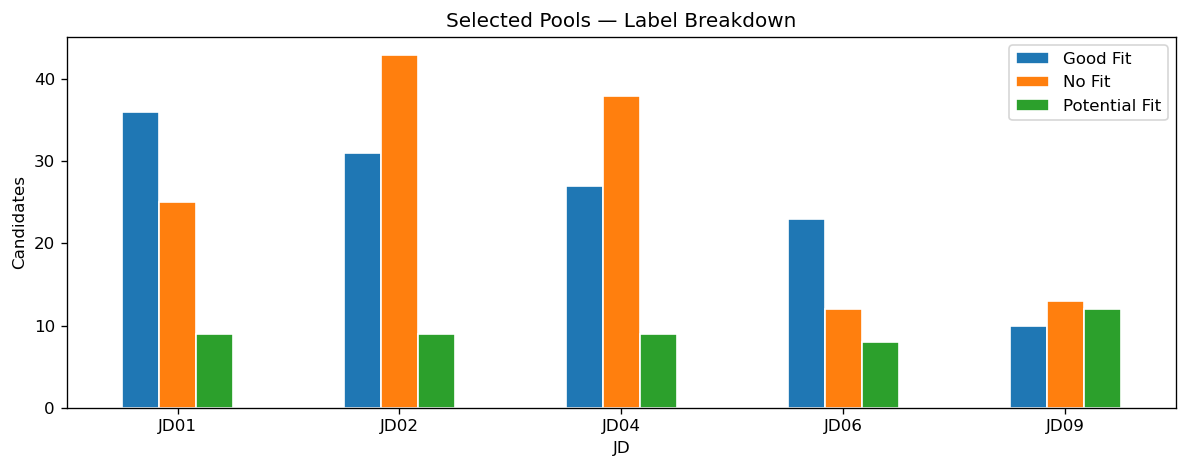

Saved: 04_selected_pools.png


In [25]:
SELECTED_JD_INDICES = [1, 2, 4, 6, 9]

if not SELECTED_JD_INDICES:
    print('Fill in SELECTED_JD_INDICES above then re-run.')
else:
    selected_pools = []
    for idx in SELECTED_JD_INDICES:
        jd_text = viable_jds.index[idx - 1]
        jd_row  = viable_jds.iloc[idx - 1]
        pool    = df[df['job_description_text'] == jd_text].copy()
        pool['jd_id']    = f'JD{idx:02d}'
        pool['label_num'] = pool['label'].map({col_good:1, col_pot:2, col_no:3})
        selected_pools.append(pool)
        print(f'JD{idx:02d}  Good:{int(jd_row[col_good])}  '
              f'Potential:{int(jd_row[col_pot])}  '
              f'No Fit:{int(jd_row[col_no])}  '
              f'Total:{int(jd_row["total"])}')

    final_pool = pd.concat(selected_pools, ignore_index=True)
    print(f'\nTotal candidates: {len(final_pool)}')
    print(f'JDs selected    : {len(SELECTED_JD_INDICES)}')

    fig, ax = plt.subplots(figsize=(10, 4))
    summary = final_pool.groupby(['jd_id','label']).size().unstack(fill_value=0)
    summary.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title('Selected Pools — Label Breakdown')
    ax.set_xlabel('JD')
    ax.set_ylabel('Candidates')
    ax.tick_params(axis='x', rotation=0)
    ax.legend()
    plt.tight_layout()
    plt.savefig('04_selected_pools.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 04_selected_pools.png')

---
## Step 7 — Save

Run only when satisfied with Step 6.

In [20]:
# Required splits per JD
REQUIRED_GOOD = 5
REQUIRED_POTENTIAL = 8
REQUIRED_NOFIT = 7

# Manually chosen JDs (from the filtered list of 11)
SELECTED_JD_INDICES = [1, 2, 4, 6, 9]   # JD01, JD02, JD04, JD06, JD09

# Get the actual JD texts for these indices (from the valid_jds DataFrame)
valid_jds = jd_label[
    (jd_label[col_good] >= REQUIRED_GOOD) &
    (jd_label[col_pot] >= REQUIRED_POTENTIAL) &
    (jd_label[col_no] >= REQUIRED_NOFIT)
].copy()

selected_jd_texts = [valid_jds.index[i-1] for i in SELECTED_JD_INDICES]

print(f"Selected JDs: {SELECTED_JD_INDICES}")
print(f"Corresponding JD texts found: {len(selected_jd_texts)}")
print()

# Sample and save
filtered_pools = []
for idx, jd_text in zip(SELECTED_JD_INDICES, selected_jd_texts):
    jd_pairs = df[df['job_description_text'] == jd_text]
    
    good_sample = jd_pairs[jd_pairs['label'] == col_good].sample(n=REQUIRED_GOOD, random_state=42)
    pot_sample = jd_pairs[jd_pairs['label'] == col_pot].sample(n=REQUIRED_POTENTIAL, random_state=42)
    nofit_sample = jd_pairs[jd_pairs['label'] == col_no].sample(n=REQUIRED_NOFIT, random_state=42)
    
    sampled = pd.concat([good_sample, pot_sample, nofit_sample], ignore_index=True)
    sampled['jd_id'] = f'JD{idx:02d}'
    sampled['label_num'] = sampled['label'].map({col_good: 1, col_pot: 2, col_no: 3})
    filtered_pools.append(sampled)
    
    print(f"JD{idx:02d}: Good={len(good_sample)}, Pot={len(pot_sample)}, NoFit={len(nofit_sample)}")

final_pool = pd.concat(filtered_pools, ignore_index=True)

# Save
save_cols = ['jd_id', 'job_description_text', 'resume_text', 'label', 'label_num']
final_pool[save_cols].to_csv('selected_dataset.csv', index=False)

jd_only = final_pool[['jd_id', 'job_description_text']].drop_duplicates()
jd_only.to_csv('selected_jds.csv', index=False)

print("\n" + "="*50)
print("SAVED: selected_dataset.csv")
print(f"  {len(final_pool)} resume-JD pairs (expected {len(SELECTED_JD_INDICES) * 20})")
print()
print("SAVED: selected_jds.csv")
print(f"  {len(jd_only)} JDs")
print()
print("Label distribution:")
print(final_pool['label'].value_counts().to_string())
print()
print("Next step: convert resume_text to DOCX files")


Selected JDs: [1, 2, 4, 6, 9]
Corresponding JD texts found: 5

JD01: Good=5, Pot=8, NoFit=7
JD02: Good=5, Pot=8, NoFit=7
JD04: Good=5, Pot=8, NoFit=7
JD06: Good=5, Pot=8, NoFit=7
JD09: Good=5, Pot=8, NoFit=7

SAVED: selected_dataset.csv
  100 resume-JD pairs (expected 100)

SAVED: selected_jds.csv
  5 JDs

Label distribution:
label
Potential Fit    40
No Fit           35
Good Fit         25

Next step: convert resume_text to DOCX files
